# **Linear Regression**

1. Simple linear Regression - 1 Input !output

2. Multi linear Regression- Many Inputs and ! Output   



# **Multi linear Regression- Many Inuts and 1 Ouptput


In [2]:
import pandas as pd

car = pd.read_csv('/content/mtcars.csv')
car[:2]


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.0,6,160.0,110,3.9,2.620,16.46,0,1,4,4
1,21.0,6,160.0,110,3.9,2.875,17.02,0,1,4,4


In [3]:
car.shape

(32, 11)

In [4]:
car['cyl'].value_counts()

,count
cyl,
8,14
4,11
6,7


In [5]:
# Data Preprocessing
# Missing values - isna()
# Noise/Outliers - boxplot

In [6]:
# Missing values - isna()
car.isna().sum()

,0
mpg,0
cyl,0
disp,0
hp,0
drat,0
wt,0
qsec,0
vs,0
am,0
gear,0


# From above table we can conclude we dont have any missing values present in the available columns

<Axes: >

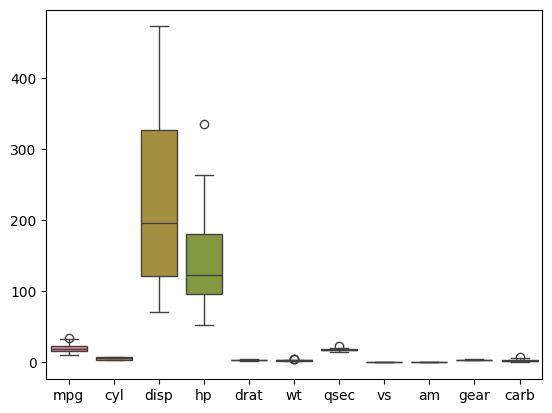

In [7]:
import seaborn as sns
sns.boxplot(data=car)

In [8]:
car.columns

Index(['mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear',
       'carb'],
      dtype='object')

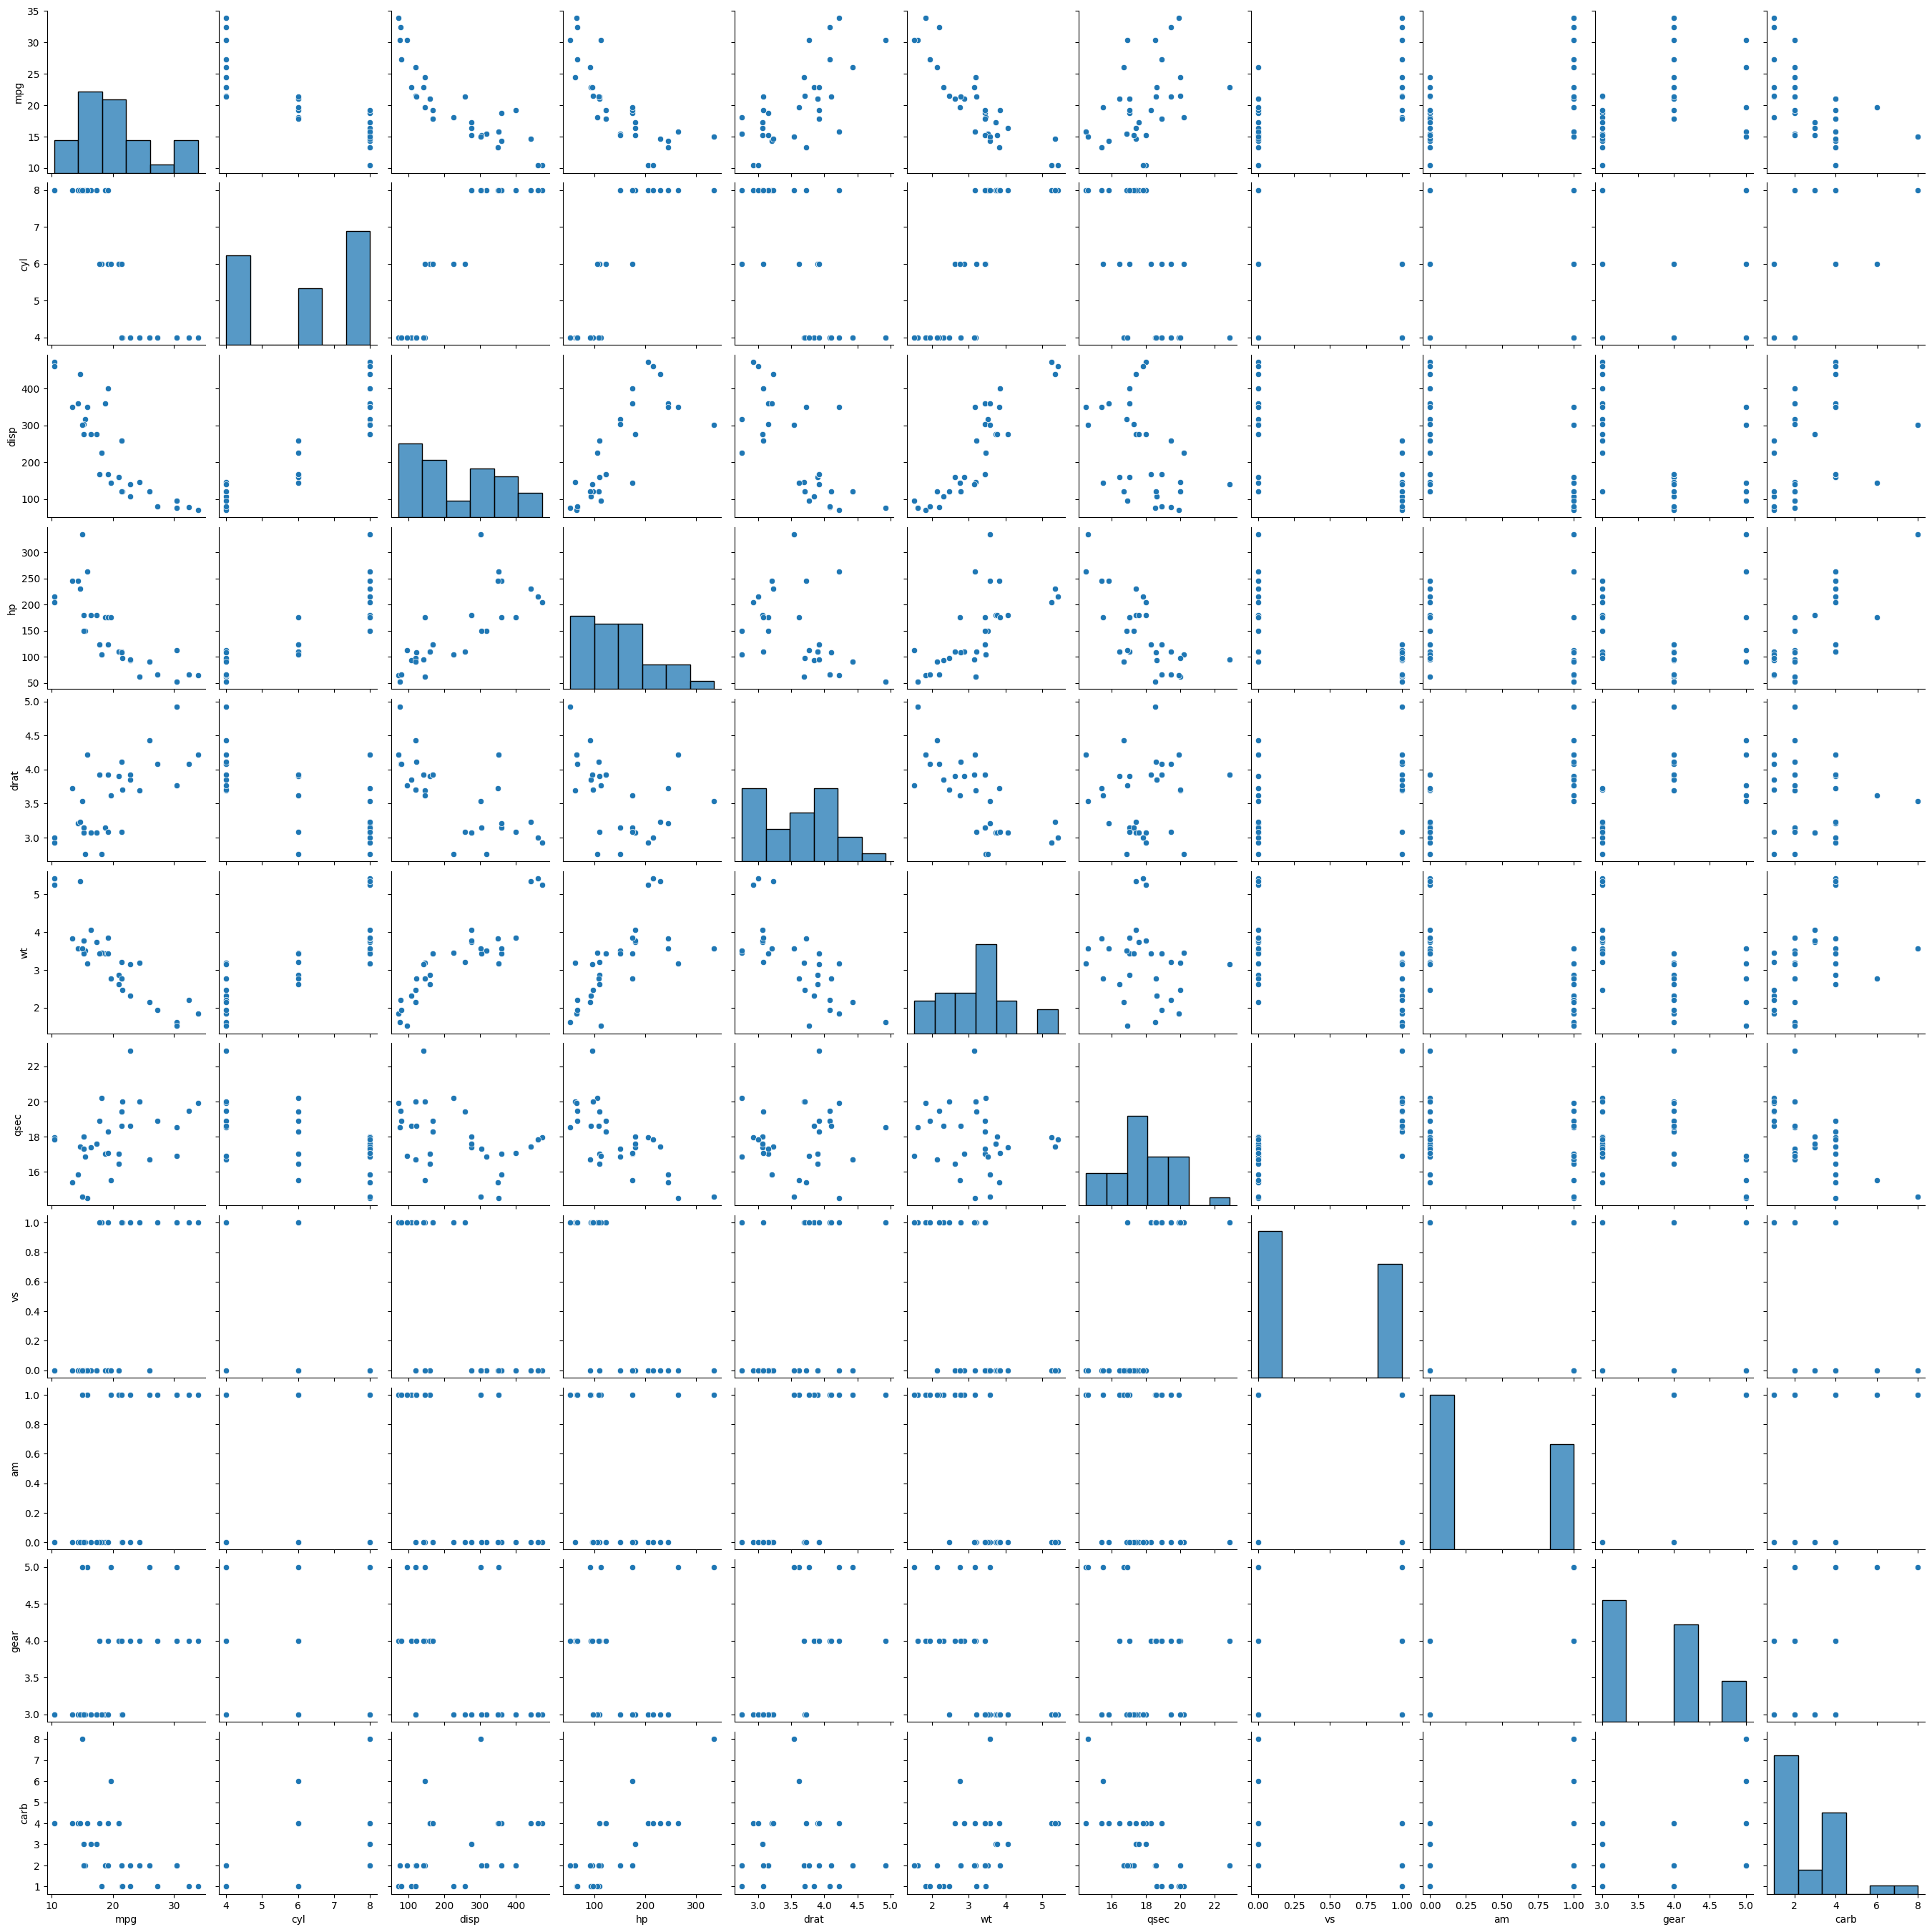

In [9]:
# matrix plot
sns.pairplot(data=car)

![image.png](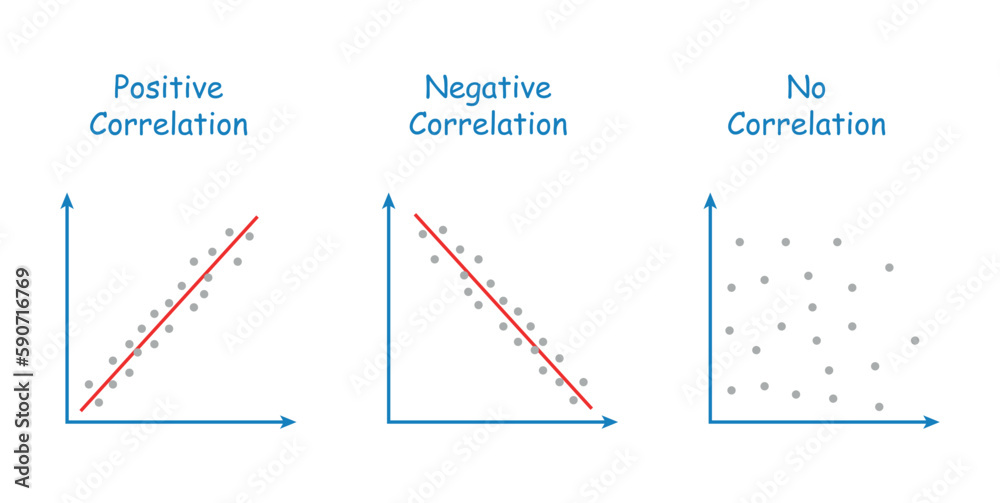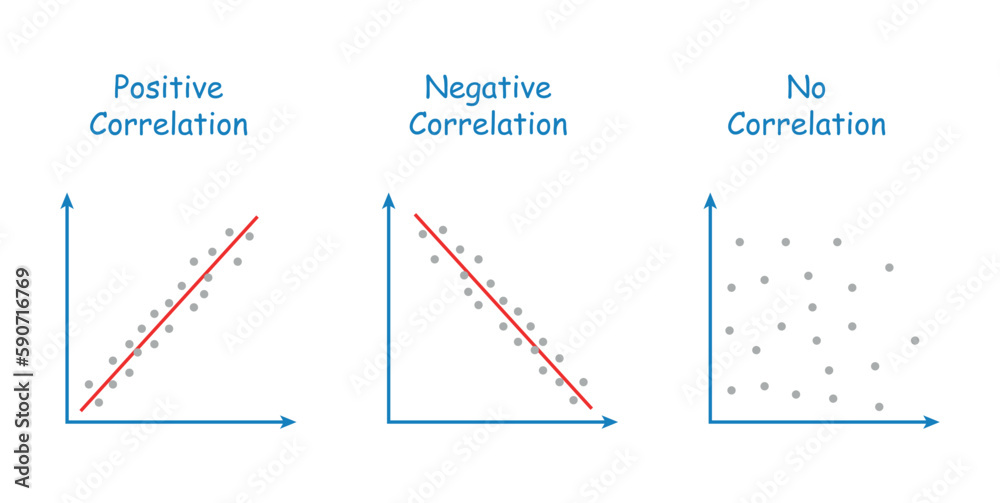)

In [10]:
# for Linear regrression algorithms always check correlation

car.corr().style.background_gradient('Reds')

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
mpg,1.000000,-0.852162,-0.847551,-0.776168,0.681172,-0.867659,0.418684,0.664039,0.599832,0.480285,-0.550925
cyl,-0.852162,1.000000,0.902033,0.832447,-0.699938,0.782496,-0.591242,-0.810812,-0.522607,-0.492687,0.526988
disp,-0.847551,0.902033,1.000000,0.790949,-0.710214,0.887980,-0.433698,-0.710416,-0.591227,-0.555569,0.394977
hp,-0.776168,0.832447,0.790949,1.000000,-0.448759,0.658748,-0.708223,-0.723097,-0.243204,-0.125704,0.749812
drat,0.681172,-0.699938,-0.710214,-0.448759,1.000000,-0.712441,0.091205,0.440278,0.712711,0.699610,-0.090790
wt,-0.867659,0.782496,0.887980,0.658748,-0.712441,1.000000,-0.174716,-0.554916,-0.692495,-0.583287,0.427606
qsec,0.418684,-0.591242,-0.433698,-0.708223,0.091205,-0.174716,1.000000,0.744535,-0.229861,-0.212682,-0.656249
vs,0.664039,-0.810812,-0.710416,-0.723097,0.440278,-0.554916,0.744535,1.000000,0.168345,0.206023,-0.569607
am,0.599832,-0.522607,-0.591227,-0.243204,0.712711,-0.692495,-0.229861,0.168345,1.000000,0.794059,0.057534
gear,0.480285,-0.492687,-0.555569,-0.125704,0.699610,-0.583287,-0.212682,0.206023,0.794059,1.000000,0.274073


In [11]:
# Prepare Data
X = car[[ 'cyl','disp','wt','hp']]

y = car['mpg']

# Problem Statememnt: Build a ML model to predict the Milage per gallon on the basis of cyl, disp, hp, wt

In [12]:
# import algorithm

from sklearn.linear_model import LinearRegression

In [13]:
model = LinearRegression()

model.fit(X,y)

LinearRegression()

In [14]:
# select first 5 records for testing
test_data = X.head()
test_data

,cyl,disp,wt,hp
0,6,160.0,2.620,110
1,6,160.0,2.875,110
2,4,108.0,2.320,93
3,6,258.0,3.215,110
4,8,360.0,3.440,175


In [15]:
# now use above test data for prediction

y_pred = model.predict(test_data)
y_pred #predicted

array([22.56804806, 21.58530266, 26.05685052, 21.41170091, 17.80606112])

In [16]:
y.head().values  # actual

array([21. , 21. , 22.8, 21.4, 18.7])

In [17]:
21. - 22.57   # error

-1.5700000000000003

In [18]:
model.score(X,y)  #score of data /means how good your data is

0.8486347934212335

In [19]:
# score- range 0-1

In [20]:
car.shape

(32, 11)

# **Data Spliting**

![model.png](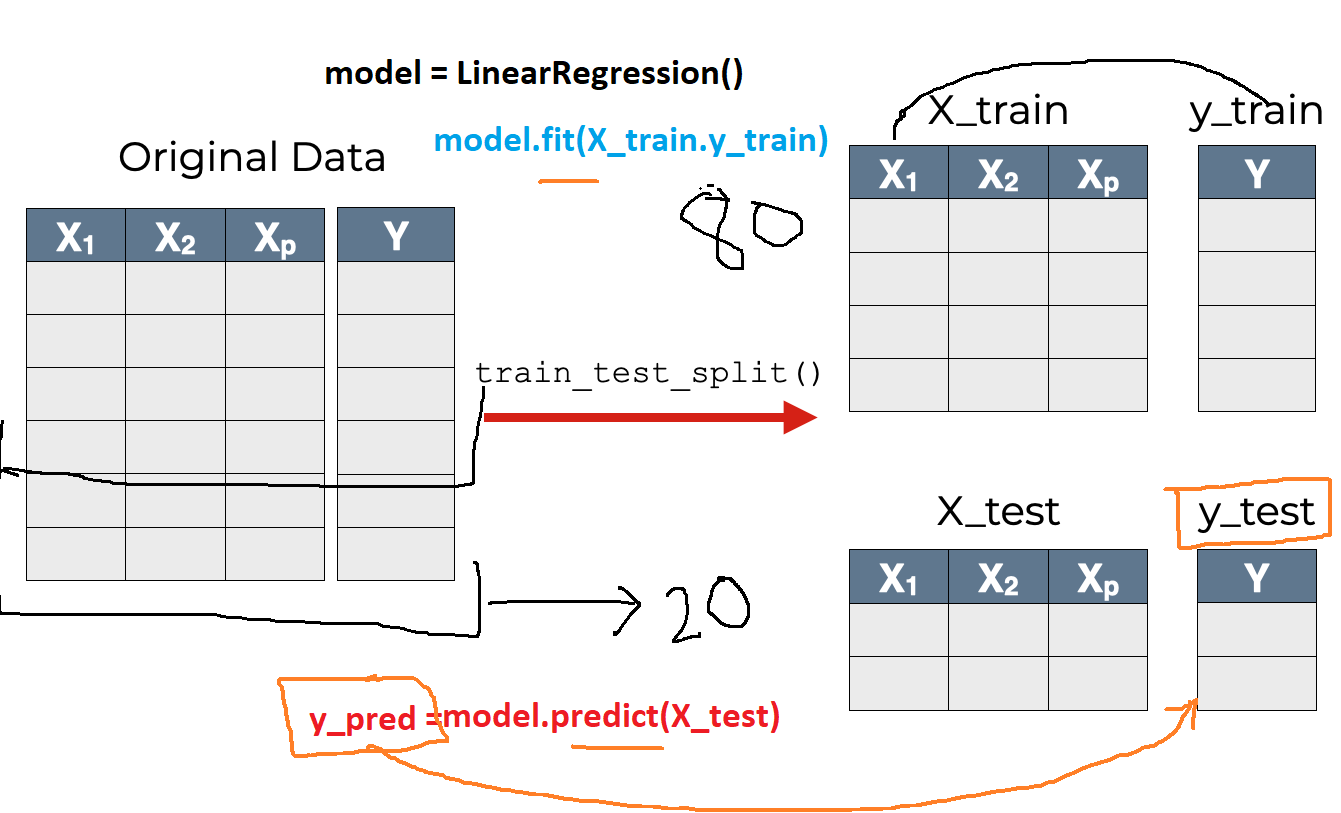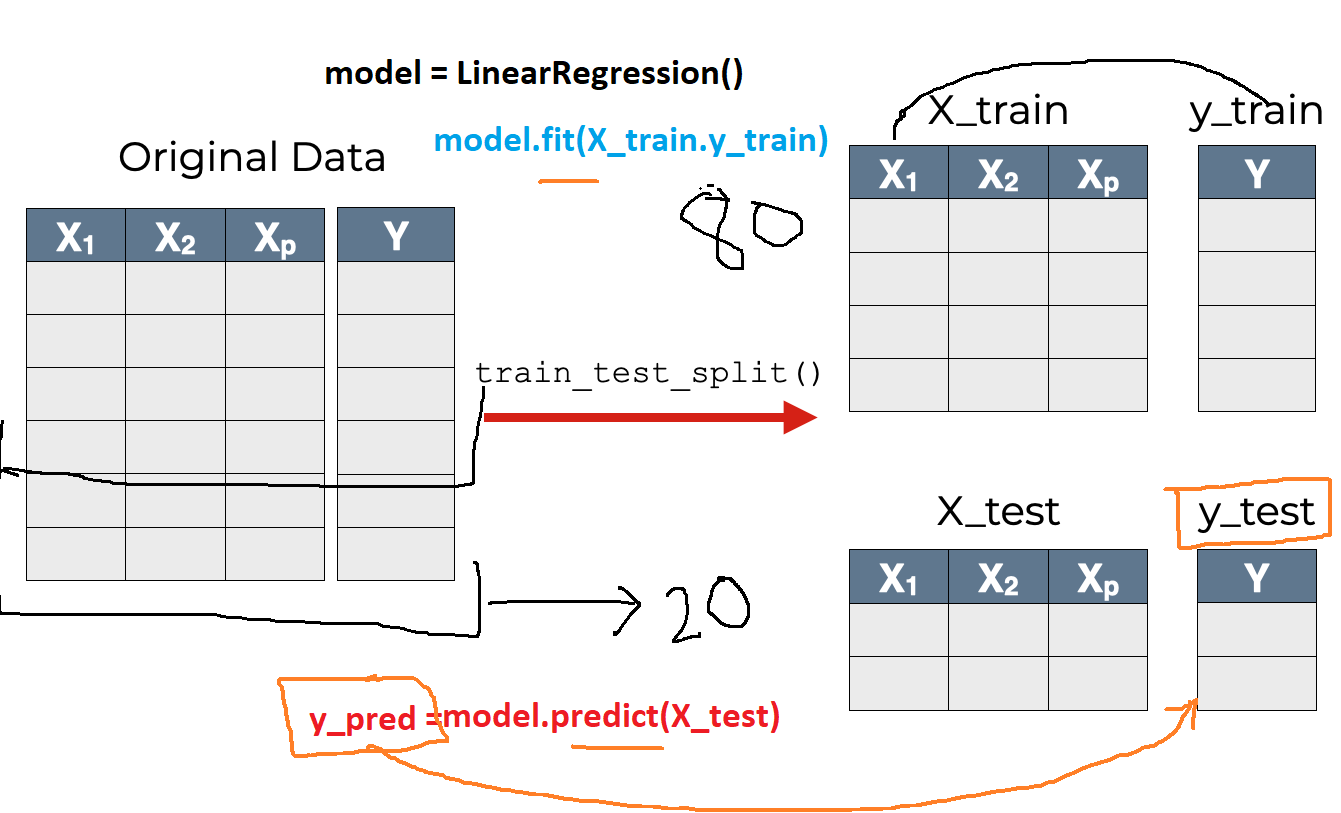)To split the data we can go with different strategies

80% Training |20% Testing

70% Training |30% Testing

In [21]:
X[:2]

,cyl,disp,wt,hp
0,6,160.0,2.620,110
1,6,160.0,2.875,110


In [22]:
y[:2]

,mpg
0,21.0
1,21.0


In [23]:
# lets split the data
from sklearn.model_selection import train_test_split

In [24]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2)  # 80|20

In [25]:
#X_train[:2]
len(X_train)

25

In [26]:
32*.8

25.6

In [27]:
# import algorithm

from sklearn.linear_model import LinearRegression
# Train the Model on training data
model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [28]:
model.score(X_train,y_train),model.score(X_test,y_test)

(0.860873880987004, 0.7928943846444664)

In [29]:
# TESTING

y_pred = model.predict(X_test)
y_pred # predicted mpg

array([17.86072707, 12.62879489, 21.76641637, 26.53377592, 23.34406687,
       24.07346431, 20.47893754])

In [30]:
y_test.values  # actual mpg

array([15.5, 10.4, 21.4, 32.4, 22.8, 21.4, 18.1])

In [31]:
model.score(X_test,y_pred)*100

100.0

## **Regression Metrics**

also called as cost function/loss function Performance metrics/measures

In [32]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [33]:
#MAE
mean_absolute_error(y_test,y_pred)

2.345518733507508

In [34]:
# error = act-pred
# 20 - 18 = 2
# 20- 30 = -10

In [35]:
abs(-10)

10

In [36]:
mean_squared_error(y_test,y_pred)

8.312881268754213

In [37]:
# check score of model
r2_score(y_test,y_pred)

0.7928943846444664

In [38]:
y_pred

array([17.86072707, 12.62879489, 21.76641637, 26.53377592, 23.34406687,
       24.07346431, 20.47893754])

In [39]:
X_train[:5]

,cyl,disp,wt,hp
23,8,350.0,3.840,245
27,4,95.1,1.513,113
6,8,360.0,3.570,245
26,4,120.3,2.140,91
11,8,275.8,4.070,180


In [40]:
# Assume this model is good model
# Deployment
# Serialization Process---> Conver Python Code to Object/Byte code
model

LinearRegression()

In [42]:
# perform picking
import pickle

pickle.dump(model,open('model.pkl','wb'))